In [1]:
from mlp.MLP import standardMLP
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
seed = 2
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
Esq = []

for _ in range(10000):
    testinput = torch.randn(1000, 1)
    w = torch.randn(1, 1) 
    y = torch.nn.SELU()(testinput * w)
    Esq.append(torch.mean(y).item())

print(f"Mean output: {np.mean(Esq):.4f}, Std: {np.std(Esq):.4f}")

Mean output: 0.0139, Std: 0.1101


In [3]:
Esq = []
for _ in range(1000):
    testinput = torch.randn(1000, 1)
    w = torch.randn(1, 100) 
    y = torch.nn.Tanh()(testinput @ w)
    Esq.append(torch.mean(y**2).item())

print(f"Mean squared output: {np.mean(Esq):.4f}, Std: {np.std(Esq):.4f}")

Mean squared output: 0.2767, Std: 0.0217


In [4]:
covsums = []
for _ in range(1000):
    testinput = torch.randn(1000, 1)
    w = torch.randn(1, 20) * 1.7
    y = torch.nn.SiLU()(testinput @ w)
    cov = torch.cov(y.T)
    num_pairs = (cov.shape[0] * (cov.shape[0] - 1))
    cov_mean = (cov.sum() - cov.diagonal().sum()) / num_pairs
    covsums.append(cov_mean.item())

print(f"Mean covariance sum: {np.mean(covsums):.4f}, Std: {np.std(covsums):.4f}")

Mean covariance sum: 0.1504, Std: 0.0801


In [5]:
model = standardMLP([1,5000,1])
x = torch.randn(10000, 1)
with torch.no_grad():
    h1 = model.net[:3](x)
    h3 = model.net(x)
    print(f"h1 mean: {h1.mean():.3f}, var: {h1.var():.3f}")
    print(f"h3 mean: {h3.mean():.3f}, var: {h3.var():.3f}")

h1 mean: -0.000, var: 0.998
h3 mean: -0.043, var: 0.553


In [6]:
seed = 1
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
vars = []
means = []
for _ in range(10000):
    model = standardMLP([1,5,5,5,1])
    x_init = torch.randn(1000, 1)
    y_init = model(x_init)
    vars.append(torch.var(y_init).item())
    means.append(torch.mean(y_init).item())

print(f"Mean variance: {np.mean(vars):.4f}")
print(f"Variance of variances: {np.var(vars):.4f}")
print(f"Mean of means: {np.mean(means):.4f}")
print(f"Variance of means: {np.var(means):.4f}")

Mean variance: 0.9795
Variance of variances: 1.8957
Mean of means: 0.0006
Variance of means: 0.0187


In [7]:
seed = 1
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
means = []
vars = []
covs = []
for _ in range(10000):
    testinput = torch.randn(10000, 1)
    w1 = torch.randn(1, 20)
    y1 = torch.nn.SELU()(testinput @ w1)
    cov = torch.cov(y1.T)
    num_pairs = (cov.shape[0] * (cov.shape[0] - 1))
    cov_mean = (cov.sum() - cov.diagonal().sum()) / num_pairs
    covs.append(cov_mean.item())
    w2 = torch.randn(20,1) * np.sqrt(1/(20))
    y2 = y1 @ w2
    means.append(torch.mean(y2).item())
    vars.append(torch.var(y2).item())

print(f"Mean of means: {np.mean(means):.4f}, Var: {np.var(means):.4f}")
print(f"Mean of variances: {np.mean(vars):.4f}, Var: {np.var(vars):.4f}")
print(f"Mean of covariances: {np.mean(covs):.4f}, Var: {np.var(covs):.4f}")

Mean of means: -0.0006, Var: 0.0112
Mean of variances: 0.8508, Var: 1.4674
Mean of covariances: 0.0108, Var: 0.0037


In [8]:
seed = 2
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
means = []
vars = []
covs = []
for _ in range(10000):
    testinput = torch.randn(10000, 20)
    w1 = torch.randn(1, 20)
    y1 = torch.nn.SELU()(testinput * w1)
    cov = torch.cov(y1.T)
    num_pairs = (cov.shape[0] * (cov.shape[0] - 1))
    cov_mean = (cov.sum() - cov.diagonal().sum()) / num_pairs
    covs.append(cov_mean.item())
    w2 = torch.randn(20,1) * np.sqrt(1/20)
    y2 = y1 @ w2
    means.append(torch.mean(y2).item())
    vars.append(torch.var(y2).item())

print(f"Mean of means: {np.mean(means):.4f}, Var: {np.var(means):.4f}")
print(f"Mean of variances: {np.mean(vars):.4f}, Var: {np.var(vars):.4f}")
print(f"Mean of covariances: {np.mean(covs):.4f}, Var: {np.var(covs):.4f}")

Mean of means: 0.0006, Var: 0.0117
Mean of variances: 0.8629, Var: 0.2197
Mean of covariances: -0.0000, Var: 0.0000


In [9]:
seed = 1
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
means = []
vars = []
ys = []
hmeans = []
hvars = []
hs = []
input_dim = 1
for _ in range(1000):
    testinput = torch.randn(10000, input_dim)
    w = torch.randn(input_dim, 1) * np.sqrt(1/input_dim)
    h = testinput @ w
    hmeans.append(torch.mean(h).item())
    hvars.append(torch.var(h).item())
    hs.append(h)
    y = torch.nn.SELU()(h)
    means.append(torch.mean(y).item())
    vars.append(torch.var(y).item())
    ys.append(y)

print(f"Mean of means: {np.mean(means):.4f}, Var: {np.var(means):.4f}")
print(f"Mean of variances: {np.mean(vars):.4f}, Var: {np.var(vars):.4f}")
print(f"Mean of h means: {np.mean(hmeans):.4f}, Var: {np.var(hmeans):.4f}")
print(f"Mean of h vars: {np.mean(hvars):.4f}, Var: {np.var(hvars):.4f}")


Mean of means: 0.0145, Var: 0.0103
Mean of variances: 0.8667, Var: 0.8875
Mean of h means: 0.0002, Var: 0.0001
Mean of h vars: 0.9930, Var: 1.7763


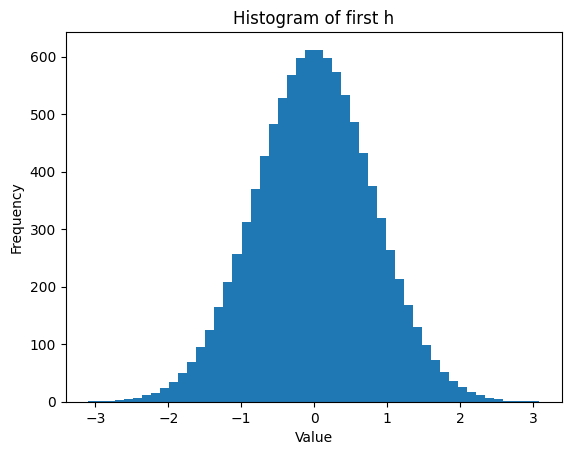

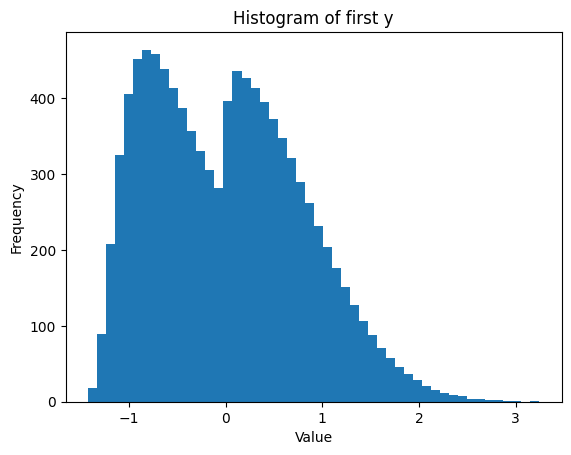

In [10]:
sorths = map(lambda h: torch.sort(h, dim=0).values, hs)
havg = torch.mean(torch.stack(list(sorths)), dim=0)
plt.hist(havg.numpy(), bins=50)
plt.title("Histogram of first h")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

sortys = map(lambda y: torch.sort(y, dim=0).values, ys)
yavg = torch.mean(torch.stack(list(sortys)), dim=0)
plt.hist(yavg.numpy(), bins=50)
plt.title("Histogram of first y")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [11]:
# seed = 1
# device = "cpu"
# torch.manual_seed(seed)
# np.random.seed(seed)
# random.seed(seed)
# means = []
# vars = []
# covs = []
# for _ in range(10000):
#     testinput = torch.randn(10000, 1)
#     w1 = torch.randn(1, 20)
#     y1 = torch.nn.SELU()(testinput @ w1)
#     cov = torch.cov(y1.T)
#     num_pairs = (cov.shape[0] * (cov.shape[0] - 1))
#     cov_mean = (cov.sum() - cov.diagonal().sum()) / num_pairs
#     covs.append(cov_mean.item())
#     w2 = torch.randn(20,1) * np.sqrt(1/(20))
#     y2 = torch.nn.SELU()(y1 @ w2)
#     means.append(torch.mean(y2).item())
#     vars.append(torch.var(y2).item())

# print(f"Mean of means: {np.mean(means):.4f}, Var: {np.var(means):.4f}")
# print(f"Mean of variances: {np.mean(vars):.4f}, Var: {np.var(vars):.4f}")
# print(f"Mean of covariances: {np.mean(covs):.4f}, Var: {np.var(covs):.4f}")

In [22]:
def R2(preds, targets):
    """
    Coefficient of Determination (R²).
    Note: R² can be negative if predictions are worse than the mean baseline.
    R² = 1 - (SS_res / SS_tot)
    """
    pred_mean = torch.mean(preds, dim=0, keepdim=True)
    target_mean = torch.mean(targets, dim=0, keepdim=True)
    SS_res = torch.sum((targets - preds)**2, dim=0)
    SS_tot = torch.sum((targets - target_mean)**2, dim=0)
    r2_score = 1 - (SS_res / (SS_tot + 1e-8))
    return torch.nan_to_num(r2_score)


seed = 2
device = "cpu"
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

function_set = [
    ("x",lambda x: x[:]),
    ("x**2",lambda x: x[:]**2),
    ("x**3",lambda x: x[:]**3),
    ("x**4",lambda x: x[:]**4),
    ("x**5",lambda x: x[:]**5),
    ("1/x",lambda x: 1/(x[:] + 1e-8)),
    ("1/x**2",lambda x: 1/(x[:]**2 + 1e-8)),
    ("1/x**3",lambda x: 1/(x[:]**3 + 1e-8)),
    ("1/x**4",lambda x: 1/(x[:]**4 + 1e-8)),
    ("1/x**5",lambda x: 1/(x[:]**5 + 1e-8)),
    ("sin(x)",lambda x: torch.sin(x[:])),
    ("cos(x)",lambda x: torch.cos(x[:])),
    ("sin(2x)",lambda x: torch.sin(2*x[:])),
    ("cos(2x)",lambda x: torch.cos(2*x[:])),
    ("sin(x**2)",lambda x: torch.sin(x[:]**2)),
    ("cos(x**2)",lambda x: torch.cos(x[:]**2)),
    ("tan(x)",lambda x: torch.tan(x[:])),
    ("exp(x)",lambda x: torch.exp(x[:])),
    ("sqrt(x)",lambda x: torch.sqrt(torch.abs(x[:]))),
    ("log(x)",lambda x: torch.log(torch.abs(x[:])+1e-8)),
    ("exp(-x**2)",lambda x: torch.exp(-x[:]**2))
]
model = standardMLP([1,20,20,1])
# function = (lambda x: -996 * x[:]**3 + 12.8 * x[:]**2 -24.6 * x[:] -0.115)
function = (lambda x: x[:]**3 - 2 * x[:]**2 + 3 * x[:] + 1)
X_all = torch.randn(2200, 1)
y_all = function(X_all)
ymean = torch.mean(y_all)
ystd = torch.std(y_all)
y_all = (y_all - ymean) / ystd
X_train = X_all[:2000]
y_train = y_all[:2000]
X_test = X_all[2000:]
y_test = y_all[2000:]
dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# # Initialize KAN and fit the model

x_init = torch.randn(10000, 1)
y_init = model(x_init)
print(f"Variance of input: {torch.var(x_init).item():.4f}")
print(f"Variance of output: {torch.var(y_init).item():.4f}")
print(f"Mean of output: {torch.mean(y_init).item():.4f}")

Variance of input: 0.9753
Variance of output: 0.4459
Mean of output: 0.0201


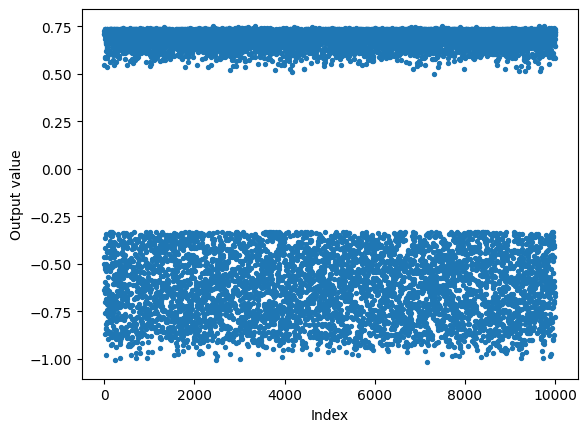

In [23]:

plt.scatter(np.arange(len(y_init)), y_init.detach().cpu().numpy().squeeze(), s=8)
plt.xlabel("Index")
plt.ylabel("Output value")
plt.show()

In [24]:
model.fit(dataset=dataset, steps=75, lr=1e-2, batch_size=32, early_stop=None, weight_decay=0, seed=seed);

In [15]:
# X_train = torch.randn(2000, 1)
# y_train = (lambda x: x[:]**4)(X_train)
# X_test = torch.randn(200, 1)
# y_test = (lambda x: x[:]**4)(X_test)
# dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# model = standardMLP([1,3,1])
# model.fit(dataset=dataset, steps=300, lr=1e-3, batch_size=64, early_stop=None, weight_decay=0);

# X_train = torch.randn(2000, 1)
# y_train = (lambda x: x[:]**5)(X_train)
# X_test = torch.randn(200, 1)
# y_test = (lambda x: x[:]**5)(X_test)
# dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}
# model = standardMLP([1,3,1])
# model.fit(dataset=dataset, steps=300, lr=1e-3, batch_size=64, early_stop=None, weight_decay=0);

In [16]:
# y_pred_test = model(dataset['test_input'])
# y_pred_train = model(dataset['train_input'])
# mse_test = torch.nn.MSELoss()(y_pred_test, dataset['test_label']).item()
# mse_train = torch.nn.MSELoss()(y_pred_train, dataset['train_label']).item()
# R2_score_kan = R2(y_pred_test, dataset['test_label']).item()
# print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}, R² Score: {R2_score_kan:.4f}")

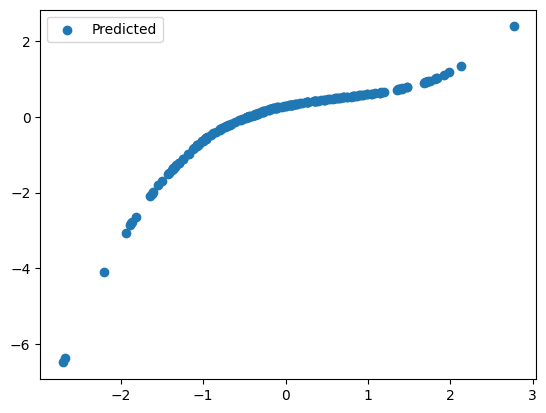

In [25]:
y_pred = model(dataset['test_input'])
# plt.scatter(dataset['test_input'].numpy(), y_test.numpy(), label='True')
plt.scatter(dataset['test_input'].numpy(), y_pred.detach().numpy(), label='Predicted')
# plt.scatter(dataset['train_input'].numpy(), dataset['train_label'].numpy(), label='Train Data', alpha=0.5)
plt.legend()


